# DAY 2-1. Feature Engineering : 피처셋과 데이터 분할
DAY 1 설계(PDF 11장, 14장)를 모델 입력으로 고정한다.

| 항목 | 내용 |
|---|---|
| 입력 | `data/features_cycle100.csv` (01_EDA 출력, cycle 2\~100 측정값) |
| 피처셋 A | dQ_logvar (원논문 variance 모델) |
| 피처셋 B | dQ_logvar + QD_slope_91_100 (DAY 1 기준 ①\~④ 통과) |
| 피처셋 C (가설 검증용) | B + dQ_logmin, dQ_mean, QD_2, QD_slope_2_100, QD_icpt_2_100 |
| Target | log10(cycle_life) |
| 분할 | Train/Valid = Batch 1 내 정책 단위 GroupShuffleSplit(20%), seed 0\~19 · Test = Batch 2 (필수), Batch 3 (추가) |

출력 : `data/model_input.csv`, `data/splits.json`

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.spines.top': False, 'axes.spines.right': False})
DATA, FIG = '../data', '../figures/model'
import os; os.makedirs(FIG, exist_ok=True)
F = pd.read_csv(f'{DATA}/features_cycle100.csv')
FS = pd.read_csv(f'{DATA}/features_sensitivity_b1c0-4.csv')
print(F.batch.value_counts().sort_index().to_dict(), '| 민감도 셀', len(FS))

{'b1': 36, 'b2': 39, 'b3': 44} | 민감도 셀 5


## 1. 피처셋 정의
`knee`, `slope_pre`, `slope_post`는 EOL까지의 곡선으로 계산한 EDA 해석용 값이라 모델 입력에서 제외한다 (미래 정보 누수).
`newstruct`, `policy`는 피처가 아니라 분할(그룹)과 잔차 분석에만 쓴다.

In [2]:
SETS = {
    'A': ['dQ_logvar'],
    'B': ['dQ_logvar', 'QD_slope_91_100'],
    'C': ['dQ_logvar', 'QD_slope_91_100', 'dQ_logmin', 'dQ_mean', 'QD_2', 'QD_slope_2_100', 'QD_icpt_2_100'],
}
LEAK = ['knee', 'slope_pre', 'slope_post']
assert not any(f in LEAK for s in SETS.values() for f in s)
ALL = sorted(set(sum(SETS.values(), [])))
print('결측 :', F[ALL].isna().sum().sum(), '| 민감도 셀 결측 :', FS[ALL].isna().sum().sum())

def vif(X):
    X = (X - X.mean()) / X.std(); o = {}
    for c in X:
        A = np.column_stack([np.ones(len(X)), X.drop(columns=c).values]); y = X[c].values
        b = np.linalg.lstsq(A, y, rcond=None)[0]; r2 = 1 - ((y - A @ b) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        o[c] = 1 / max(1 - r2, 1e-6)
    return pd.Series(o)
b1 = F[F.batch == 'b1']
for k in ['B', 'C']:
    print(f'셋 {k} VIF (b1) :', vif(b1[SETS[k]]).round(1).to_dict())
r = pd.DataFrame({t: F[F.batch == t][ALL].corrwith(F[F.batch == t].log_life) for t in ['b1', 'b2', 'b3']}).round(3)
r['sign_same'] = np.sign(r[['b1', 'b2', 'b3']]).nunique(axis=1) == 1
print(r.loc[ALL])

결측 : 0 | 민감도 셀 결측 : 0
셋 B VIF (b1) : {'dQ_logvar': 1.4, 'QD_slope_91_100': 1.4}
셋 C VIF (b1) : {'dQ_logvar': 378.4, 'QD_slope_91_100': 18.2, 'dQ_logmin': 448.3, 'dQ_mean': 29.7, 'QD_2': 921.1, 'QD_slope_2_100': 18.8, 'QD_icpt_2_100': 863.4}
                    b1     b2     b3  sign_same
QD_2             0.157 -0.217  0.171      False
QD_icpt_2_100    0.143 -0.150  0.145      False
QD_slope_2_100   0.556 -0.372  0.432      False
QD_slope_91_100  0.535  0.303  0.459       True
dQ_logmin       -0.821 -0.901 -0.744       True
dQ_logvar       -0.844 -0.918 -0.762       True
dQ_mean          0.798  0.791  0.720       True


## 2. 모델 입력 테이블
학습·검증·테스트 셀과 민감도 분석용 b1 c0\~c4(원논문 보정 수명)를 한 테이블에 둔다. `role`로 구분한다.

In [3]:
COLS = ['key', 'batch', 'policy', 'newstruct', 'life', 'log_life'] + ALL
M = F[COLS].copy(); M['role'] = M.batch.map({'b1': 'train', 'b2': 'test', 'b3': 'test_extra'})
S = FS.copy(); S['newstruct'] = 0; S = S[COLS]; S['role'] = 'sensitivity'
M = pd.concat([M, S], ignore_index=True)
M.to_csv(f'{DATA}/model_input.csv', index=False)
print(M.role.value_counts().to_dict())

{'test_extra': 44, 'test': 39, 'train': 36, 'sensitivity': 5}


## 3. 데이터 분할 : 정책 단위 hold-out × 20 seed
- 같은 충전 정책 셀이 Train과 Valid에 나뉘면 정책 정보가 새므로 **정책(group) 단위**로 나눈다 (DAY 1 Q4)
- b1 36셀, 정책 20개 → 정책의 20%(4개)를 Valid로 → Valid 6\~8셀
- 단일 분할은 운에 좌우되므로 seed 0\~19의 20개 분할을 만들고, 모든 모델을 같은 20개 분할로 비교한다
- 대표 seed는 0. 리포트에는 대표 seed 값과 20회 평균 ± 표준편차를 함께 쓴다

Valid 셀 수 : {6: 2, 7: 14, 8: 4}
seed 0 Valid 정책 : ['4.8C(80%)-4.8C', '6C(30%)-3.6C', '8C(25%)-3.6C', '8C(35%)-3.6C']


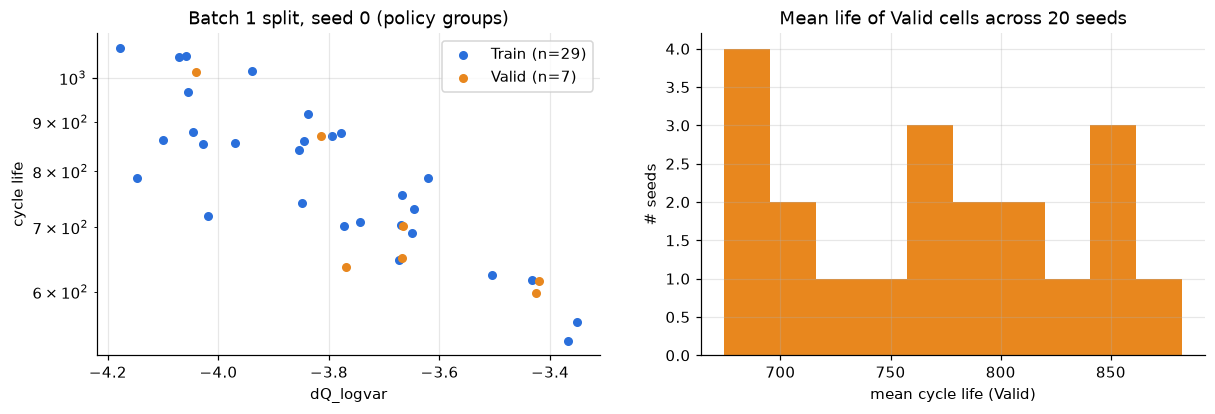

In [4]:
T = M[M.role == 'train'].reset_index(drop=True)
splits = []
for seed in range(20):
    tr, va = next(GroupShuffleSplit(n_splits=1, test_size=.2, random_state=seed).split(T, groups=T.policy))
    assert not set(T.policy[tr]) & set(T.policy[va])
    splits.append(dict(seed=seed, train=T.key[tr].tolist(), valid=T.key[va].tolist()))
json.dump(splits, open(f'{DATA}/splits.json', 'w'), indent=1)
json.dump(SETS, open(f'{DATA}/feature_sets.json', 'w'), indent=1)
n_va = pd.Series([len(s['valid']) for s in splits])
print('Valid 셀 수 :', n_va.value_counts().sort_index().to_dict())
s0 = splits[0]
print('seed 0 Valid 정책 :', sorted(T.set_index('key').loc[s0['valid'], 'policy'].unique()))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
v = T.set_index('key')
for k, col, lab in ((s0['train'], '#2a6fdb', 'Train'), (s0['valid'], '#e8871e', 'Valid')):
    ax[0].scatter(v.loc[k, 'dQ_logvar'], v.loc[k, 'life'], c=col, s=24, label=f'{lab} (n={len(k)})')
ax[0].set(yscale='log', title='Batch 1 split, seed 0 (policy groups)', xlabel='dQ_logvar', ylabel='cycle life'); ax[0].legend()
ax[1].hist([T.set_index('key').loc[s['valid'], 'life'].mean() for s in splits], bins=10, color='#e8871e')
ax[1].set(title='Mean life of Valid cells across 20 seeds', xlabel='mean cycle life (Valid)', ylabel='# seeds')
plt.savefig(f'{FIG}/split_overview.png', dpi=170, bbox_inches='tight'); plt.show()